<a href="https://colab.research.google.com/github/ArkanUbaidillah/DeepLearning_B_2411537001_ArkanUbaidillahWarman/blob/main/Praktikum2/2411537001_ArkanUbaidillahWarman_Program2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Deep Learning Minggu 2
## Modul 2: Convolutional Neural Network (CNN) untuk Klasifikasi Citra

Nama: Arkan Ubaidillah Warman  
NIM: 2411537001  
Kelas: B  
Departemen Informatika, Fakultas Teknologi Informasi, Universitas Andalas



## Persiapan
Impor library yang dibutuhkan.

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader

Pengaturan seed dan informasi lingkungan.

In [ ]:
# Pengaturan seed agar hasil dapat diulang
import time
import numpy as np
torch.manual_seed(42)
np.random.seed(42)
print("PyTorch:", torch.__version__)
print("torchvision:", torchvision.__version__)
print("Device:", "cuda" if torch.cuda.is_available() else "cpu")

PyTorch: 2.14.0+cu130
torchvision: 0.29.0+cu130
Device: cpu


## Langkah Praktikum
### 1. Load dataset dan transformasi

In [ ]:
# 1. Load dataset dan transformasi
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

trainset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
testset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

trainloader = DataLoader(trainset, batch_size=64, shuffle=True)
testloader = DataLoader(testset, batch_size=64, shuffle=False)

In [ ]:
print("Jumlah data latih:", len(trainset))
print("Jumlah data uji  :", len(testset))
print("Ukuran satu citra:", tuple(trainset[0][0].shape))
print("Jumlah kelas     :", len(trainset.classes))

Jumlah data latih: 60000
Jumlah data uji  : 10000
Ukuran satu citra: (1, 28, 28)
Jumlah kelas     : 10


### 2. Definisikan model CNN

In [ ]:
# 2. Definisikan model CNN
class CNNModel(nn.Module):
    def __init__(self):
        super(CNNModel, self).__init__()
        self.conv1 = nn.Conv2d(1, 16, 3, padding=1)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(16, 32, 3, padding=1)
        self.fc1 = nn.Linear(32 * 7 * 7, 128)
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = self.pool(nn.ReLU()(self.conv1(x)))
        x = self.pool(nn.ReLU()(self.conv2(x)))
        x = x.view(-1, 32 * 7 * 7)
        x = nn.ReLU()(self.fc1(x))
        x = self.fc2(x)
        return x

### 3. Inisialisasi model, loss, optimizer

In [ ]:
# 3. Inisialisasi model, loss, optimizer
model = CNNModel()
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

print(model)
print("Total parameter:", sum(p.numel() for p in model.parameters()))

CNNModel(
  (conv1): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv2): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (fc1): Linear(in_features=1568, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)
Total parameter: 206922


### 4. Training

In [ ]:
# 4. Training
epochs = 5
train_loss = []
start_time = time.time()
for epoch in range(epochs):
    running_loss = 0.0
    for images, labels in trainloader:
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
    train_loss.append(running_loss/len(trainloader))
    print(f'Epoch [{epoch+1}/{epochs}], Loss: {running_loss/len(trainloader):.4f}')
waktu_cnn1 = time.time() - start_time
print(f'Waktu training: {waktu_cnn1:.2f} detik')

Epoch [1/5], Loss: 0.2096


Epoch [2/5], Loss: 0.0589


Epoch [3/5], Loss: 0.0417


Epoch [4/5], Loss: 0.0320


Epoch [5/5], Loss: 0.0254
Waktu training: 80.45 detik


### 5. Evaluasi

In [ ]:
# 5. Evaluasi
correct, total = 0, 0
with torch.no_grad():
    for images, labels in testloader:
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()
print(f'Akurasi Uji: {100 * correct / total:.2f}%')

Akurasi Uji: 98.70%


### 6. Plot grafik loss

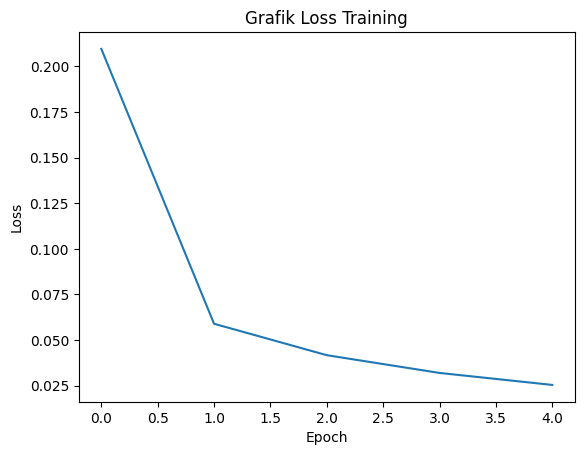

In [ ]:
# 6. Plot grafik loss
plt.plot(train_loss)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Grafik Loss Training')
plt.show()

## Analisis Hasil
### 1. Nilai loss setiap epoch dan grafiknya
Loss training turun pada setiap epoch, dari 0,2096 pada epoch 1 menjadi 0,0254 pada epoch 5. Penurunan terbesar terjadi antara epoch 1 dan epoch 2 (0,2096 ke 0,0589). Setelah epoch 2 kurva melandai, dan penurunan per epoch mengecil menjadi sekitar 0,001 sampai 0,008.

Epoch 1: 0.2096
Epoch 2: 0.0589
Epoch 3: 0.0417
Epoch 4: 0.0320
Epoch 5: 0.0254


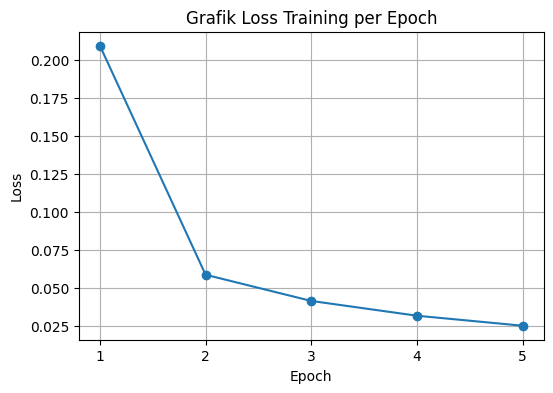

In [ ]:
# Analisis 1: nilai loss setiap epoch dan grafiknya
for i, l in enumerate(train_loss, start=1):
    print(f'Epoch {i}: {l:.4f}')

plt.figure(figsize=(6, 4))
plt.plot(range(1, epochs + 1), train_loss, marker='o')
plt.xticks(range(1, epochs + 1))
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Grafik Loss Training per Epoch')
plt.grid(True)
plt.show()

### 2. Akurasi training dan testing

In [ ]:
# Analisis 2: akurasi training dan testing
def hitung_akurasi(model, loader):
    benar, jumlah = 0, 0
    model.eval()
    with torch.no_grad():
        for images, labels in loader:
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            jumlah += labels.size(0)
            benar += (predicted == labels).sum().item()
    return 100 * benar / jumlah

akurasi_train = hitung_akurasi(model, trainloader)
akurasi_test = hitung_akurasi(model, testloader)
print(f'Akurasi Training: {akurasi_train:.2f}%')
print(f'Akurasi Testing : {akurasi_test:.2f}%')
print(f'Selisih         : {akurasi_train - akurasi_test:.2f}%')

Akurasi Training: 99.25%
Akurasi Testing : 98.70%
Selisih         : 0.55%


### 3. Analisis performa dan overfitting
Akurasi training sebesar 99,25% dan akurasi testing sebesar 98,70%. Selisih kedua akurasi adalah 0,55 poin persentase.

Model belum menunjukkan overfitting yang berarti. Selisih akurasi training dan testing hanya 0,55 poin, sehingga model mengenali data uji hampir sama baiknya dengan data latih. Model menggeneralisasi dengan baik pada MNIST. Praktikum ini tidak menyediakan loss validasi, jadi penilaian bertumpu pada selisih akurasi. Loss training yang masih turun pada epoch 5 menandakan pelatihan lebih lama masih mungkin menaikkan akurasi training. Jika hal itu terjadi tanpa kenaikan akurasi uji, selisih akan melebar dan overfitting perlu diperiksa ulang.

### 4. Contoh citra beserta prediksi model
Lima belas citra pertama dari data uji dipilih sebagai contoh. Model memprediksi semua citra tersebut dengan benar, termasuk angka 9 dan angka 6 yang bentuknya berbeda dari tulisan standar.

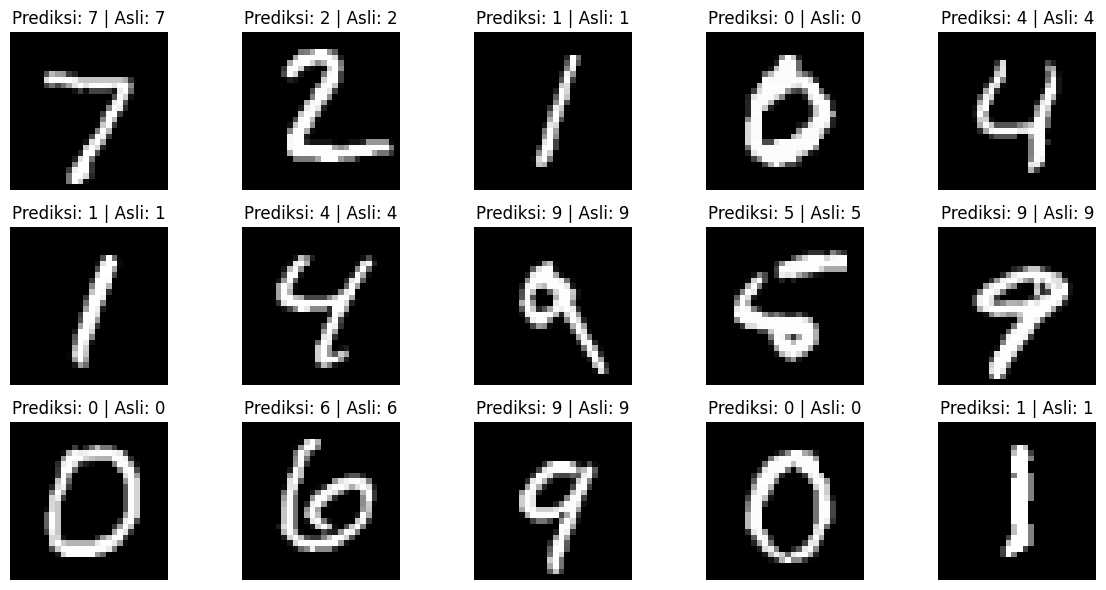

In [ ]:
# Analisis 4: contoh citra beserta prediksi model
model.eval()
images, labels = next(iter(testloader))
with torch.no_grad():
    outputs = model(images)
    _, predicted = torch.max(outputs, 1)

plt.figure(figsize=(12, 6))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title(f'Prediksi: {predicted[i].item()} | Asli: {labels[i].item()}')
    plt.axis('off')
plt.tight_layout()
plt.show()

## Pertanyaan Reflektif
**1. Mengapa CNN lebih baik dibanding MLP untuk citra?**

MLP meratakan citra menjadi vektor sehingga kehilangan informasi posisi antarpiksel. Setiap piksel terhubung ke semua neuron, jadi jumlah parameter membengkak. Untuk citra 28×28 saja, satu lapisan tersembunyi 128 neuron sudah memerlukan 784 × 128 = 100.352 bobot.

CNN mempertahankan struktur spasial. Kernel yang sama bergeser di seluruh citra (weight sharing), sehingga jumlah parameter jauh lebih kecil dan fitur seperti tepi dikenali di posisi mana pun. Lapisan awal menangkap tepi dan garis, lapisan berikutnya menyusunnya menjadi bentuk yang lebih kompleks.

**2. Apa fungsi pooling layer dalam CNN?**

Pooling layer mengecilkan dimensi peta fitur. Pada praktikum ini MaxPool2d(2, 2) mengambil nilai terbesar dari setiap blok 2×2 sehingga ukuran peta fitur turun separuh (28×28 menjadi 14×14, lalu 7×7). Pengecilan ini mengurangi jumlah parameter dan komputasi di lapisan berikutnya, dan membuat model lebih tahan terhadap pergeseran kecil posisi objek. Pooling juga membantu mengurangi risiko overfitting.

**3. Bagaimana pengaruh ukuran kernel terhadap hasil konvolusi?**

Kernel kecil (3×3) menangkap pola lokal yang halus seperti tepi dan sudut, dengan parameter sedikit. Kernel besar (5×5) mencakup area lebih luas sehingga menangkap pola yang lebih besar dalam satu lapisan, tetapi jumlah parameter dan waktu komputasi naik. Pada percobaan ini, kernel 5×5 pada dua lapisan menaikkan parameter dari 206.922 menjadi 215.370 dan waktu training dari 80,4 detik menjadi 97,8 detik, dengan akurasi 98,75% dibanding 98,70%.